<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/Secrets_of_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Secrets of PCA
## A Comprehensive Guide to Principal Component Analysis with Python

---

> **Welcome!** This notebook is designed for **complete beginners**. We'll go from zero to understanding one of the most powerful techniques in data science — step by step, with plenty of visuals and intuition.

### 📚 What You'll Learn

| Section | Topic |
|---------|-------|
| 1 | What is PCA & Why do we need it? |
| 2 | The Curse of Dimensionality |
| 3 | Core Math Intuition (No Fear!) |
| 4 | PCA Step-by-Step from Scratch |
| 5 | PCA with Scikit-Learn |
| 6 | How many components to choose? |
| 7 | Real-World Dataset: Iris |
| 8 | Real-World Dataset: Breast Cancer |
| 9 | Image Compression with PCA |
| 10 | PCA for Noise Reduction |
| 11 | Limitations & When NOT to Use PCA |
| 12 | PCA vs Other Techniques |
| 13 | Summary & Cheat Sheet |

### ⚙️ Prerequisites
- Basic Python (variables, loops, functions)
- Basic NumPy (arrays)
- Some familiarity with plots (Matplotlib)

**That's it! Let's dive in. 🚀**

---
## ⚙️ Setup: Install & Import Libraries

Run this cell first to import everything we need.

In [1]:
# ============================================================
#  SETUP — Run this cell first!
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris, load_breast_cancer, load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Global plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('tab10')

print('✅ All libraries imported successfully!')
print('🐍 NumPy version:', np.__version__)
print('🐼 Pandas version:', pd.__version__)

✅ All libraries imported successfully!
🐍 NumPy version: 2.0.2
🐼 Pandas version: 2.2.2


---
## 📖 Section 1: What is PCA and Why Do We Need It?

### The Big Idea

Imagine you have a dataset with **100 columns (features)**. That's hard to visualize, hard to process, and many features might be **redundant** (carrying the same information).

**Principal Component Analysis (PCA)** is a technique that:
- 📉 **Reduces** the number of features (dimensions)
- 🔄 **Transforms** data into a new coordinate system
- 💡 **Preserves** the most important information (variance)
- 🗜️ **Removes** redundancy and noise

### 🎯 Real-World Analogy

Think of taking a **3D photo** of an object. The photo is 2D but still captures the most important features of the 3D object. PCA does something similar — it finds the **best "angle"** to look at your data so you lose as little information as possible when reducing dimensions.

### When is PCA Used?
- 📊 **Visualization**: Plotting high-dimensional data in 2D or 3D
- 🏎️ **Speed**: Reducing features speeds up machine learning models
- 🎨 **Image compression**: Storing images with fewer numbers
- 🔕 **Noise reduction**: Removing noisy features
- 🔗 **Removing multicollinearity**: When features are correlated

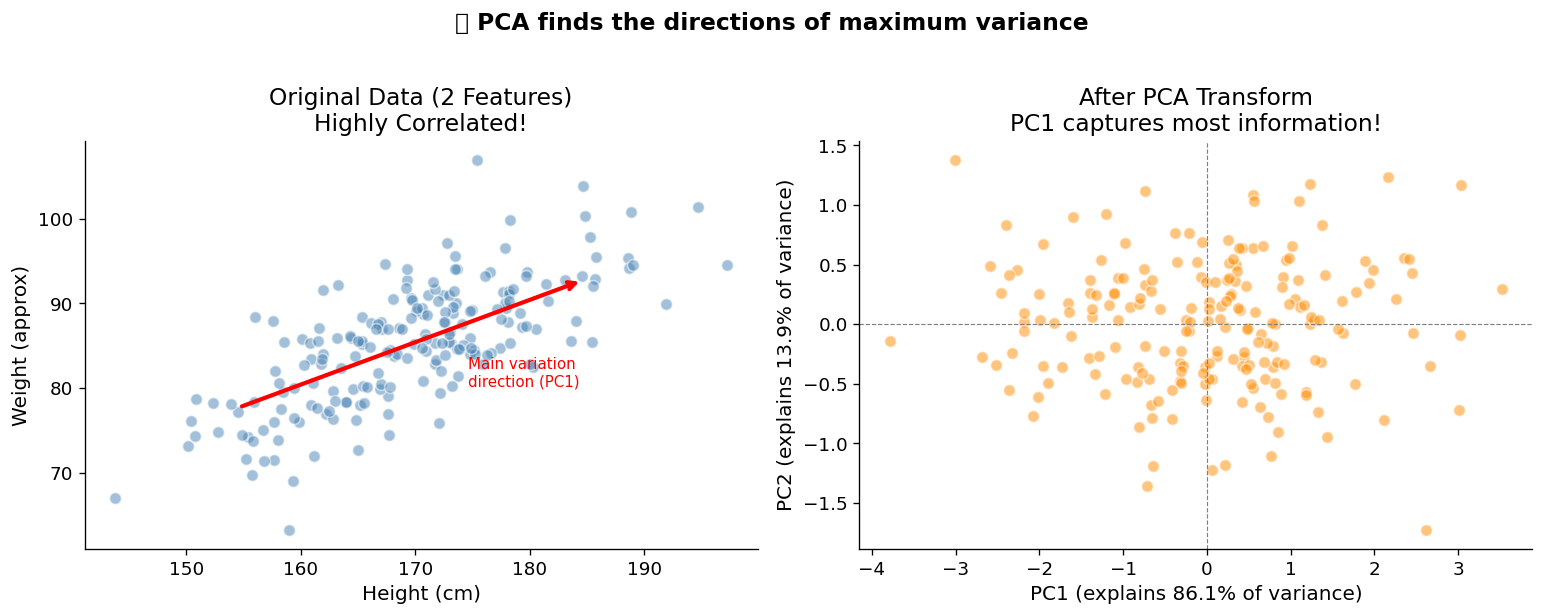


 Variance explained by each component:
   PC1: 86.1%
   PC2: 13.9%

💡 Key insight: PC1 alone captures 86.1% of all information!
   We can DROP PC2 and lose only 13.9% of information.


In [2]:
# ============================================================
#  DEMO: Why PCA? — Correlated features are redundant
# ============================================================

np.random.seed(42)

# Generate correlated data (height and weight example)
height = np.random.normal(170, 10, 200)           # Height in cm
weight = 0.5 * height + np.random.normal(0, 5, 200)  # Weight correlated with height

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Original 2D data
axes[0].scatter(height, weight, alpha=0.5, color='steelblue', edgecolors='white', s=50)
axes[0].set_xlabel('Height (cm)')
axes[0].set_ylabel('Weight (approx)')
axes[0].set_title('Original Data (2 Features)\nHighly Correlated!')

# Draw arrow showing the main direction of variation
cx, cy = np.mean(height), np.mean(weight)
axes[0].annotate('', xy=(cx+15, cy+7.5), xytext=(cx-15, cy-7.5),
                 arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
axes[0].text(cx+5, cy-5, 'Main variation\ndirection (PC1)', color='red', fontsize=9)

# Apply PCA
data_2d = np.column_stack([height, weight])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_2d)
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

# Plot 2: PCA-transformed data
axes[1].scatter(data_pca[:, 0], data_pca[:, 1], alpha=0.5, color='darkorange', edgecolors='white', s=50)
axes[1].set_xlabel(f'PC1 (explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance)')
axes[1].set_ylabel(f'PC2 (explains {pca.explained_variance_ratio_[1]*100:.1f}% of variance)')
axes[1].set_title('After PCA Transform\nPC1 captures most information!')
axes[1].axhline(0, color='gray', lw=0.7, linestyle='--')
axes[1].axvline(0, color='gray', lw=0.7, linestyle='--')

plt.suptitle('💡 PCA finds the directions of maximum variance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n Variance explained by each component:')
print(f'   PC1: {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'   PC2: {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'\n💡 Key insight: PC1 alone captures {pca.explained_variance_ratio_[0]*100:.1f}% of all information!')
print(f'   We can DROP PC2 and lose only {pca.explained_variance_ratio_[1]*100:.1f}% of information.')

---
## 👹 Section 2: The Curse of Dimensionality

Before understanding PCA fully, we need to understand **why high dimensions are a problem**.

### The Problem
As dimensions increase:
- 🌵 Data becomes **sparse** (points are far apart from each other)
- 📈 **Distance metrics** stop working well
- 🐌 Models become **slower** and need exponentially more data
- ⚠️ **Overfitting** becomes more likely

### Visualizing the Curse

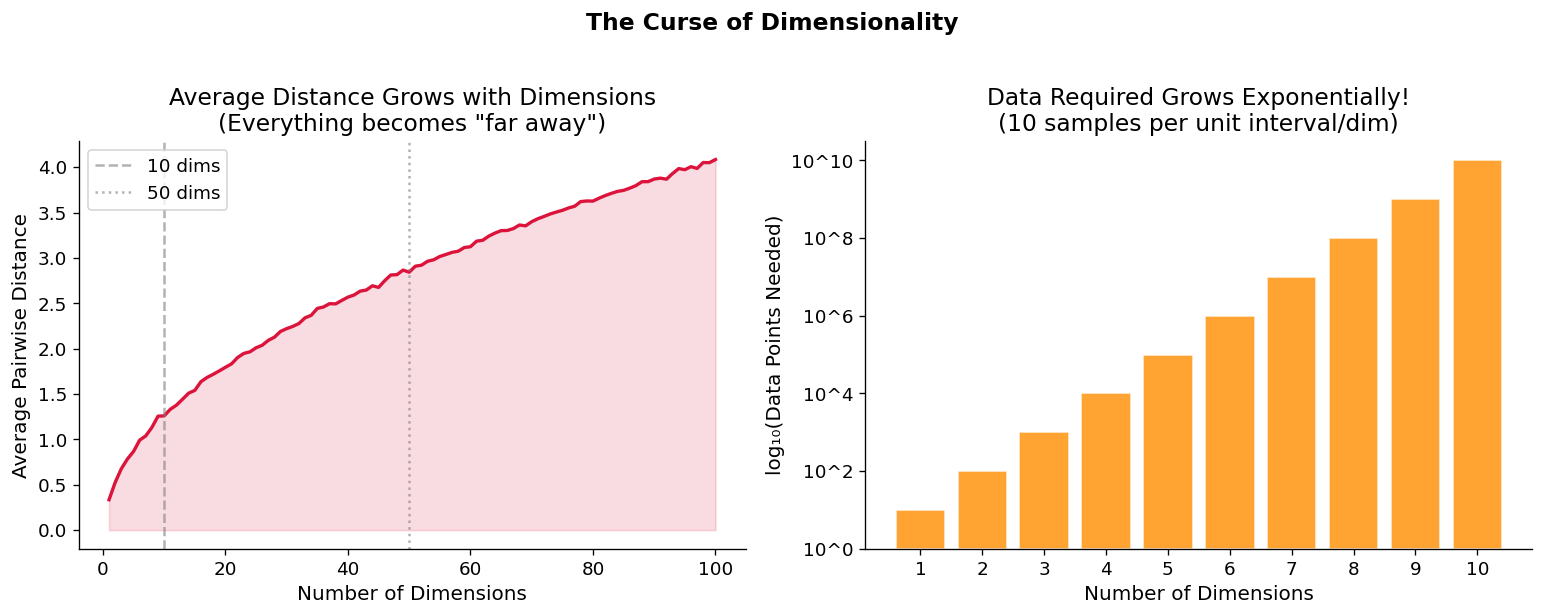

💡 Key Takeaway:
   As dimensions increase, we need exponentially MORE data.
   PCA fights this by reducing dimensions while preserving key information!


In [3]:
# ============================================================
#  DEMO: The Curse of Dimensionality
# ============================================================

np.random.seed(0)

# Show how average distance grows with dimensions
dimensions = list(range(1, 101))
avg_distances = []

for d in dimensions:
    # 500 random points in d-dimensional unit hypercube
    points = np.random.rand(500, d)
    # Compute pairwise distances for first 100 points
    dists = []
    for i in range(min(100, len(points))):
        for j in range(i+1, min(100, len(points))):
            dists.append(np.linalg.norm(points[i] - points[j]))
    avg_distances.append(np.mean(dists))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Average distance vs dimensions
axes[0].plot(dimensions, avg_distances, color='crimson', lw=2)
axes[0].fill_between(dimensions, avg_distances, alpha=0.15, color='crimson')
axes[0].set_xlabel('Number of Dimensions')
axes[0].set_ylabel('Average Pairwise Distance')
axes[0].set_title('Average Distance Grows with Dimensions\n(Everything becomes "far away")')
axes[0].axvline(x=10, color='gray', linestyle='--', alpha=0.6, label='10 dims')
axes[0].axvline(x=50, color='gray', linestyle=':', alpha=0.6, label='50 dims')
axes[0].legend()

# Plot 2: Data needed vs dimensions (exponential growth)
dims_viz = np.arange(1, 11)
data_needed = 10 ** dims_viz  # 10 samples per unit interval per dimension
axes[1].bar(dims_viz, np.log10(data_needed), color='darkorange', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Number of Dimensions')
axes[1].set_ylabel('log₁₀(Data Points Needed)')
axes[1].set_title('Data Required Grows Exponentially!\n(10 samples per unit interval/dim)')
axes[1].set_xticks(dims_viz)
labels = [f'10^{d}' for d in dims_viz]
axes[1].set_yticklabels([f'10^{int(y)}' for y in axes[1].get_yticks()])

plt.suptitle('The Curse of Dimensionality', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 Key Takeaway:')
print('   As dimensions increase, we need exponentially MORE data.')
print('   PCA fights this by reducing dimensions while preserving key information!')

---
## 🧮 Section 3: Core Math Intuition (No Fear!)

PCA involves some linear algebra. Don't worry — we'll explain everything intuitively!

### Key Concepts

#### 1️⃣ Variance
Variance measures **how spread out** data is. PCA looks for directions of **maximum variance** — because that's where the most "interesting" information lives.

#### 2️⃣ Covariance Matrix
The **covariance matrix** shows how features are correlated with each other.
- High covariance = features move together
- PCA uses this to find redundant information

#### 3️⃣ Eigenvectors & Eigenvalues
This is the heart of PCA:
- **Eigenvectors** = the **directions** (principal components) of maximum variance
- **Eigenvalues** = **how much variance** each direction captures

Think of eigenvectors as the **"axes"** of a new coordinate system that's perfectly aligned with your data's structure.

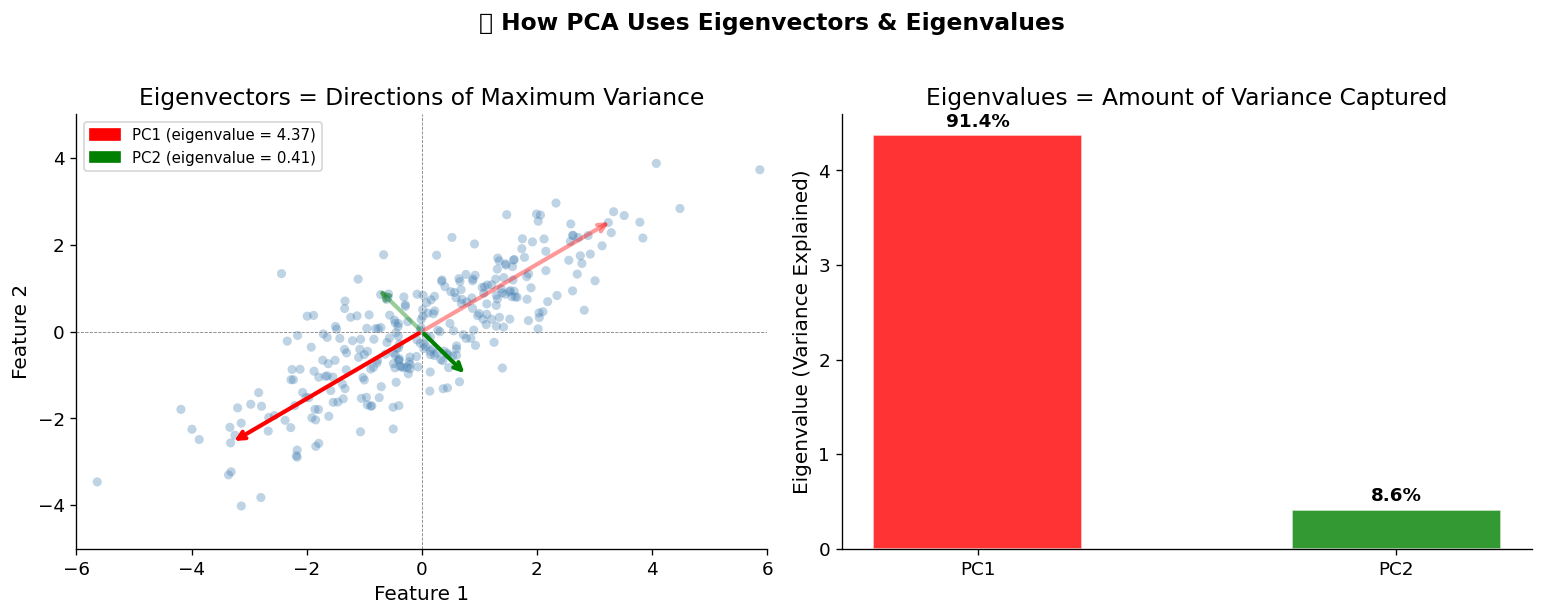

📐 Covariance Matrix:
       F1     F2
F1  2.891  1.919
F2  1.919  1.894

🔑 Eigenvectors (Principal Components):
   PC1: [-0.791 -0.612]
   PC2: [ 0.612 -0.791]

📊 Eigenvalues:
   PC1: 4.375 → explains 91.4% variance
   PC2: 0.410 → explains 8.6% variance


In [4]:
# ============================================================
#  DEMO: Eigenvectors Visualized!
# ============================================================

np.random.seed(42)

# Create correlated 2D data
mean = [0, 0]
cov = [[3, 2], [2, 2]]  # Covariance matrix
X = np.random.multivariate_normal(mean, cov, 300)

# Compute covariance matrix and eigenvectors
cov_matrix = np.cov(X.T)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort by largest eigenvalue
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Data with eigenvectors
axes[0].scatter(X[:, 0], X[:, 1], alpha=0.35, s=30, color='steelblue', edgecolors='none')

colors = ['red', 'green']
labels = ['PC1 (1st Principal Component)', 'PC2 (2nd Principal Component)']

for i in range(2):
    scale = np.sqrt(eigenvalues[i]) * 2
    ev = eigenvectors[:, i]
    axes[0].annotate('',
                     xy=(ev[0]*scale, ev[1]*scale),
                     xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color=colors[i], lw=2.5))
    axes[0].annotate('',
                     xy=(-ev[0]*scale, -ev[1]*scale),
                     xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color=colors[i], lw=2.5, alpha=0.4))

axes[0].set_xlim(-6, 6); axes[0].set_ylim(-5, 5)
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')
axes[0].set_title('Eigenvectors = Directions of Maximum Variance')
axes[0].axhline(0, color='gray', lw=0.5, linestyle='--')
axes[0].axvline(0, color='gray', lw=0.5, linestyle='--')

legend_elements = [mpatches.Patch(color='red', label=f'PC1 (eigenvalue = {eigenvalues[0]:.2f})'),
                   mpatches.Patch(color='green', label=f'PC2 (eigenvalue = {eigenvalues[1]:.2f})')]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=9)

# Right: Eigenvalues bar chart
total = np.sum(eigenvalues)
pct = [ev/total*100 for ev in eigenvalues]
bars = axes[1].bar(['PC1', 'PC2'], eigenvalues, color=['red', 'green'], alpha=0.8, edgecolor='white', width=0.5)
axes[1].set_ylabel('Eigenvalue (Variance Explained)')
axes[1].set_title('Eigenvalues = Amount of Variance Captured')
for bar, p in zip(bars, pct):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{p:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.suptitle('🧮 How PCA Uses Eigenvectors & Eigenvalues', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('📐 Covariance Matrix:')
print(pd.DataFrame(cov_matrix, columns=['F1', 'F2'], index=['F1', 'F2']).round(3))
print(f'\n🔑 Eigenvectors (Principal Components):')
print(f'   PC1: {eigenvectors[:,0].round(3)}')
print(f'   PC2: {eigenvectors[:,1].round(3)}')
print(f'\n📊 Eigenvalues:')
print(f'   PC1: {eigenvalues[0]:.3f} → explains {eigenvalues[0]/total*100:.1f}% variance')
print(f'   PC2: {eigenvalues[1]:.3f} → explains {eigenvalues[1]/total*100:.1f}% variance')

---
## 🔧 Section 4: PCA Step-by-Step from Scratch

Let's implement PCA **manually** (no sklearn!) to understand every step.

### The 6 Steps of PCA

```
Step 1: Standardize the data (mean=0, std=1)
Step 2: Compute the Covariance Matrix
Step 3: Compute Eigenvectors & Eigenvalues
Step 4: Sort by Eigenvalue (largest first)
Step 5: Select Top-k Eigenvectors
Step 6: Project data onto new axes
```

In [5]:
# ============================================================
#  PCA FROM SCRATCH — Step by Step
# ============================================================

# Sample dataset (4 features, 10 samples)
np.random.seed(7)
X_raw = np.random.randn(50, 4) @ np.array([[2,1,0,0],[0,1,0.5,0],[0,0,0.3,0],[0,0,0,0.1]])

print('=' * 55)
print('  🔧 PCA FROM SCRATCH — STEP BY STEP')
print('=' * 55)
print(f'\nOriginal Data Shape: {X_raw.shape}')
print('(50 samples, 4 features)\n')

# ── STEP 1: Standardize ──────────────────────────────────────
print('STEP 1: Standardize (zero mean, unit variance)')
print('-' * 45)
mean = np.mean(X_raw, axis=0)
std  = np.std(X_raw, axis=0)
X_std = (X_raw - mean) / std
print(f'Before — Mean: {np.mean(X_raw, axis=0).round(2)}')
print(f'After  — Mean: {np.mean(X_std, axis=0).round(10)}  ✅ (effectively zero)\n')

# ── STEP 2: Covariance Matrix ────────────────────────────────
print('STEP 2: Compute Covariance Matrix')
print('-' * 45)
cov_mat = np.cov(X_std.T)   # shape: (4, 4)
print('Covariance Matrix (4×4):')
df_cov = pd.DataFrame(cov_mat,
                       columns=[f'F{i+1}' for i in range(4)],
                       index=[f'F{i+1}' for i in range(4)])
print(df_cov.round(3), '\n')

# ── STEP 3: Eigenvectors & Eigenvalues ──────────────────────
print('STEP 3: Compute Eigenvectors & Eigenvalues')
print('-' * 45)
eigenvalues, eigenvectors = np.linalg.eigh(cov_mat)

# ── STEP 4: Sort ─────────────────────────────────────────────
print('STEP 4: Sort by Eigenvalue (largest first)')
print('-' * 45)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

total_var = np.sum(eigenvalues)
for i, (val, vec) in enumerate(zip(eigenvalues, eigenvectors.T)):
    print(f'PC{i+1}: eigenvalue={val:.3f}  '
          f'({val/total_var*100:.1f}% variance)  '
          f'vector={vec.round(3)}')

# ── STEP 5: Select Top-k ─────────────────────────────────────
k = 2
print(f'\nSTEP 5: Select top {k} components')
print('-' * 45)
W = eigenvectors[:, :k]   # Projection matrix
print(f'Projection matrix W shape: {W.shape}')
print(f'Cumulative variance retained: {np.sum(eigenvalues[:k])/total_var*100:.1f}%')

# ── STEP 6: Project data ─────────────────────────────────────
print(f'\nSTEP 6: Project data onto {k} components')
print('-' * 45)
X_pca = X_std @ W
print(f'Original data shape: {X_std.shape}  →  PCA data shape: {X_pca.shape}')
print('\n✅ PCA from scratch complete!')

  🔧 PCA FROM SCRATCH — STEP BY STEP

Original Data Shape: (50, 4)
(50 samples, 4 features)

STEP 1: Standardize (zero mean, unit variance)
---------------------------------------------
Before — Mean: [ 0.03 -0.01 -0.04 -0.  ]
After  — Mean: [-0. -0.  0.  0.]  ✅ (effectively zero)

STEP 2: Compute Covariance Matrix
---------------------------------------------
Covariance Matrix (4×4):
       F1     F2     F3     F4
F1  1.020  0.775 -0.066  0.102
F2  0.775  1.020  0.528 -0.025
F3 -0.066  0.528  1.020 -0.151
F4  0.102 -0.025 -0.151  1.020 

STEP 3: Compute Eigenvectors & Eigenvalues
---------------------------------------------
STEP 4: Sort by Eigenvalue (largest first)
---------------------------------------------
PC1: eigenvalue=1.928  (47.2% variance)  vector=[ 0.584  0.718  0.378 -0.017]
PC2: eigenvalue=1.237  (30.3% variance)  vector=[ 0.441 -0.015 -0.624  0.645]
PC3: eigenvalue=0.866  (21.2% variance)  vector=[ 0.349 -0.016 -0.543 -0.764]
PC4: eigenvalue=0.051  (1.2% variance)  vect

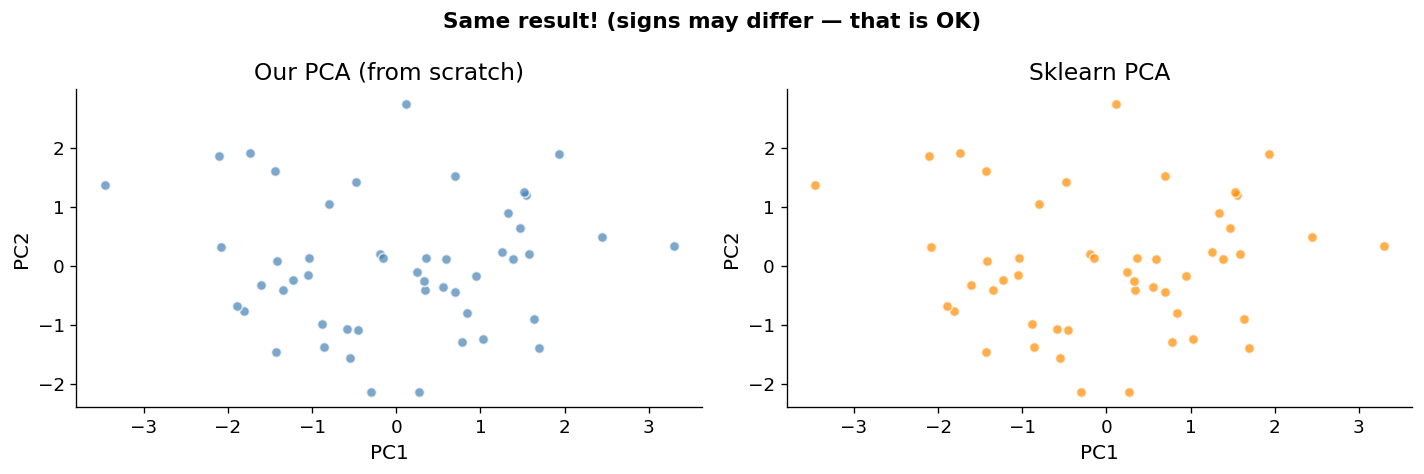

Correlation between our PC1 and sklearn PC1: 1.000000
(1.0 = identical, signs may differ — that is fine!)


In [6]:
#  VERIFY: Our PCA vs Sklearn PCA

pca_sk = PCA(n_components=2)
scaler_sk = StandardScaler()
X_sk = pca_sk.fit_transform(scaler_sk.fit_transform(X_raw))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, color='steelblue', edgecolors='white')
axes[0].set_title('Our PCA (from scratch)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

axes[1].scatter(X_sk[:, 0], X_sk[:, 1], alpha=0.7, color='darkorange', edgecolors='white')
axes[1].set_title('Sklearn PCA')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.suptitle('Same result! (signs may differ — that is OK)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Check correlation between our result and sklearn's
corr = abs(np.corrcoef(X_pca[:, 0], X_sk[:, 0])[0, 1])
print(f'Correlation between our PC1 and sklearn PC1: {corr:.6f}')
print('(1.0 = identical, signs may differ — that is fine!)')

---
## 🤖 Section 5: PCA with Scikit-Learn (The Easy Way)

Now that we understand the math, let's use **scikit-learn** — which is what you'd use in practice.

### The 3-Step Recipe
```python
# 1. Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Fit PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Inspect
print(pca.explained_variance_ratio_)
```

> ⚠️ **Always standardize before PCA!** PCA is sensitive to scale. If one feature has values 0–1000 and another 0–1, PCA will think the first feature is more important just because of its larger scale.

Dataset shape: (200, 5)  (200 samples, 5 features)


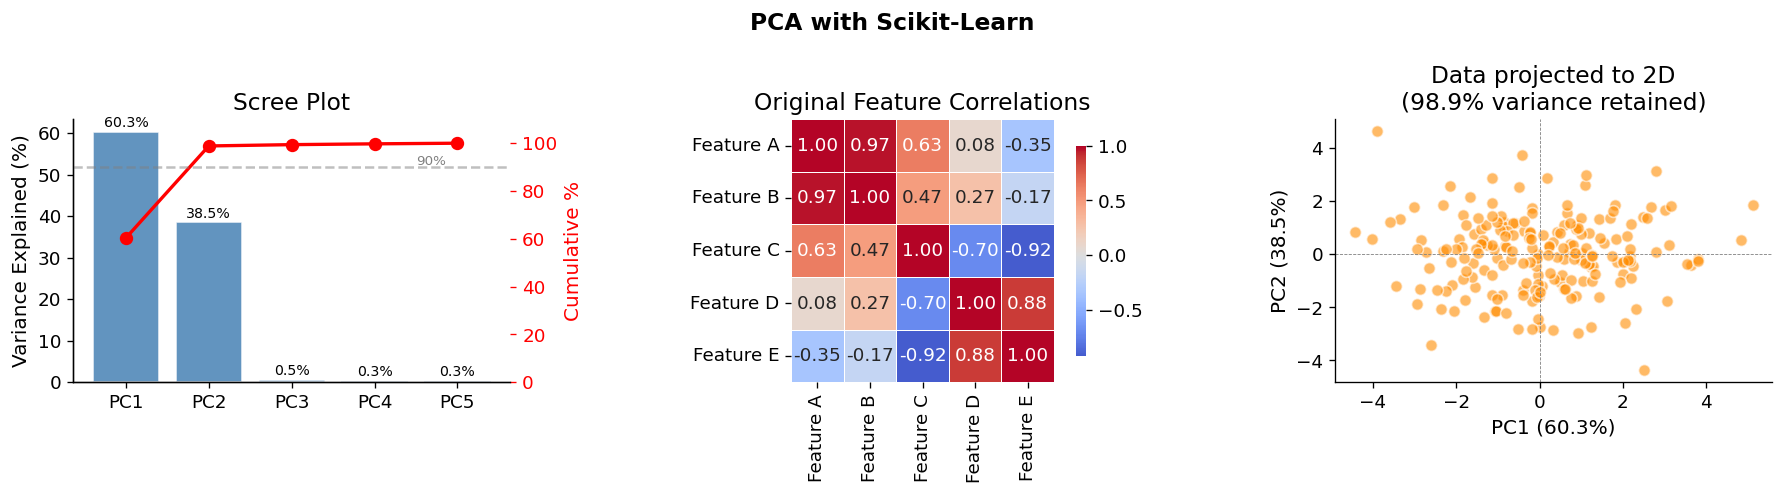


📊 Summary:
   Original features: 5
   After PCA (2 components): 2
   Compression ratio: 2.5x
   Information retained: 98.9%


In [17]:
# ============================================================
#  PCA with Scikit-Learn — Complete Demo
# ============================================================

# Generate a sample dataset with 5 features
np.random.seed(42)
n_samples = 200

# Create 5 correlated features from 2 underlying signals
signal1 = np.random.randn(n_samples)
signal2 = np.random.randn(n_samples)
noise   = 0.2

X = np.column_stack([
    2*signal1 + noise*np.random.randn(n_samples),
    1.5*signal1 + signal2*0.3 + noise*np.random.randn(n_samples),
    signal1 - signal2 + noise*np.random.randn(n_samples),
    2*signal2 + noise*np.random.randn(n_samples),
    signal2 - 0.5*signal1 + noise*np.random.randn(n_samples),
])

feature_names = ['Feature A', 'Feature B', 'Feature C', 'Feature D', 'Feature E']
print(f'Dataset shape: {X.shape}  ({n_samples} samples, 5 features)')

# ─── Step 1: Standardize ─────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ─── Step 2: Fit PCA ─────────────────────────────────────────
pca_full = PCA()  # No n_components → compute all
X_pca_full = pca_full.fit_transform(X_scaled)

# ─── Step 3: Inspect Results ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 3a: Explained variance per component
components = [f'PC{i+1}' for i in range(5)]
var_ratio  = pca_full.explained_variance_ratio_ * 100
cum_var    = np.cumsum(var_ratio)

bars = axes[0].bar(components, var_ratio, color='steelblue', alpha=0.85, edgecolor='white')
ax2 = axes[0].twinx()
ax2.plot(components, cum_var, 'ro-', lw=2, markersize=7, label='Cumulative')
ax2.set_ylabel('Cumulative %', color='red')
ax2.tick_params(axis='y', colors='red')
ax2.set_ylim(0, 110)
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot')
for bar, v in zip(bars, var_ratio):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=8.5)
ax2.axhline(90, color='gray', linestyle='--', alpha=0.5)
ax2.text(3.5, 91, '90%', color='gray', fontsize=8)

# 3b: Correlation heatmap of original data
corr_matrix = pd.DataFrame(X_scaled, columns=feature_names).corr()
sns.heatmap(corr_matrix, ax=axes[1], annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[1].set_title('Original Feature Correlations')

# 3c: 2D projection
pca_2 = PCA(n_components=2)
X_2d  = pca_2.fit_transform(X_scaled)
axes[2].scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.6, color='darkorange',
                edgecolors='white', s=50)
axes[2].set_xlabel(f'PC1 ({var_ratio[0]:.1f}%)')
axes[2].set_ylabel(f'PC2 ({var_ratio[1]:.1f}%)')
axes[2].set_title(f'Data projected to 2D\n({var_ratio[0]+var_ratio[1]:.1f}% variance retained)')
axes[2].axhline(0, color='gray', lw=0.5, ls='--')
axes[2].axvline(0, color='gray', lw=0.5, ls='--')

plt.suptitle('PCA with Scikit-Learn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📊 Summary:')
print(f'   Original features: 5')
print(f'   After PCA (2 components): 2')
print(f'   Compression ratio: {5/2:.1f}x')
print(f'   Information retained: {cum_var[1]:.1f}%')

---
## 📊 Section 6: How Many Components to Choose?

This is one of the most important decisions in PCA!

### Three Common Methods:
1. **Scree Plot + "Elbow" rule** — Look for where the curve "bends"
2. **Explained Variance Threshold** — Keep components until you reach 90% (or 95%) cumulative variance
3. **Kaiser's Rule** — Keep components with eigenvalue > 1

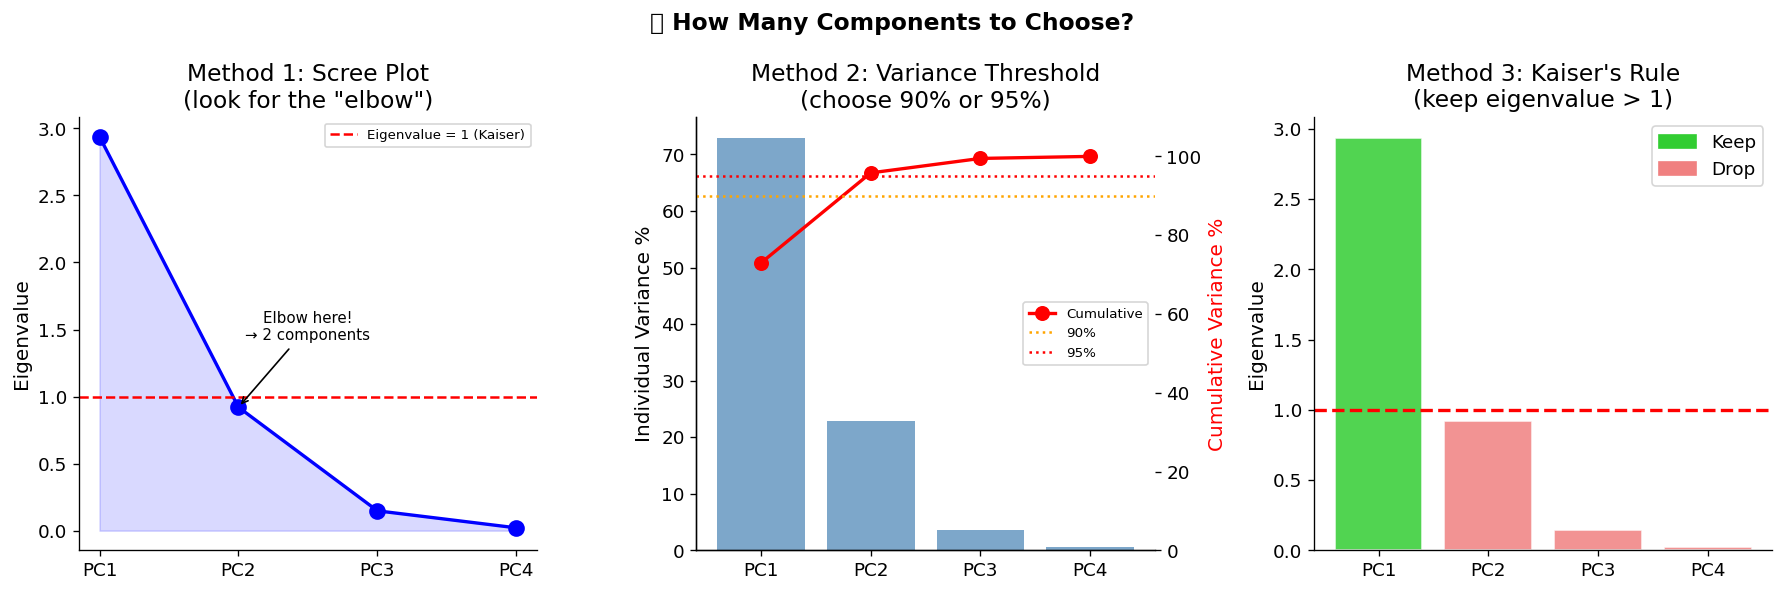


📋 Results for Iris Dataset (4 features):
   Method 1 (Elbow):      ~2 components
   Method 2 (90% threshold): 2 components (95.8%)
   Method 2 (95% threshold): 2 components (95.8%)
   Method 3 (Kaiser):     1 components

💡 For Iris: 2 components is a great choice!


In [8]:
# ============================================================
#  HOW MANY COMPONENTS? — Three Methods
# ============================================================

# Use the Iris dataset for this example
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

scaler_iris = StandardScaler()
X_iris_std  = scaler_iris.fit_transform(X_iris)

pca_iris = PCA()
pca_iris.fit(X_iris_std)

eigenvalues_iris = pca_iris.explained_variance_
var_ratio_iris   = pca_iris.explained_variance_ratio_ * 100
cum_var_iris     = np.cumsum(var_ratio_iris)
n_components     = len(var_ratio_iris)
comp_labels      = [f'PC{i+1}' for i in range(n_components)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ─── Method 1: Scree Plot (Elbow Rule) ───────────────────────
axes[0].plot(comp_labels, eigenvalues_iris, 'bo-', lw=2, markersize=9)
axes[0].fill_between(comp_labels, eigenvalues_iris, alpha=0.15, color='blue')
axes[0].axhline(1, color='red', linestyle='--', lw=1.5, label='Eigenvalue = 1 (Kaiser)')

# Mark the elbow
axes[0].annotate('Elbow here!\n→ 2 components', xy=(1, eigenvalues_iris[1]),
                 xytext=(1.5, eigenvalues_iris[1]+0.5),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=9, ha='center')

axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Method 1: Scree Plot\n(look for the "elbow")')
axes[0].legend(fontsize=8)

# ─── Method 2: Cumulative Variance ───────────────────────────
axes[1].bar(comp_labels, var_ratio_iris, color='steelblue', alpha=0.7, label='Individual')
ax_cum = axes[1].twinx()
ax_cum.plot(comp_labels, cum_var_iris, 'ro-', lw=2, markersize=8, label='Cumulative')

# Shade the 90% and 95% thresholds
for thresh, col, lbl in [(90, 'orange', '90%'), (95, 'red', '95%')]:
    ax_cum.axhline(thresh, color=col, linestyle=':', lw=1.5, label=lbl)

ax_cum.set_ylim(0, 110)
ax_cum.set_ylabel('Cumulative Variance %', color='red')
axes[1].set_ylabel('Individual Variance %')
axes[1].set_title('Method 2: Variance Threshold\n(choose 90% or 95%)')
ax_cum.legend(loc='center right', fontsize=8)

# ─── Method 3: Kaiser's Rule (eigenvalue > 1) ────────────────
colors_k = ['limegreen' if ev >= 1 else 'lightcoral' for ev in eigenvalues_iris]
bars = axes[2].bar(comp_labels, eigenvalues_iris, color=colors_k, alpha=0.85, edgecolor='white')
axes[2].axhline(1, color='red', linestyle='--', lw=2, label='Threshold = 1')
axes[2].set_ylabel('Eigenvalue')
axes[2].set_title("Method 3: Kaiser's Rule\n(keep eigenvalue > 1)")
axes[2].legend()

patches = [mpatches.Patch(color='limegreen', label='Keep'),
           mpatches.Patch(color='lightcoral', label='Drop')]
axes[2].legend(handles=patches, loc='upper right')

plt.suptitle('📊 How Many Components to Choose?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📋 Results for Iris Dataset (4 features):')
print(f'   Method 1 (Elbow):      ~2 components')
n_90 = np.argmax(cum_var_iris >= 90) + 1
n_95 = np.argmax(cum_var_iris >= 95) + 1
n_kaiser = np.sum(eigenvalues_iris >= 1)
print(f'   Method 2 (90% threshold): {n_90} components ({cum_var_iris[n_90-1]:.1f}%)')
print(f'   Method 2 (95% threshold): {n_95} components ({cum_var_iris[n_95-1]:.1f}%)')
print(f'   Method 3 (Kaiser):     {n_kaiser} components')
print(f'\n💡 For Iris: 2 components is a great choice!')

---
## 🌸 Section 7: Real-World Dataset — Iris

The **Iris dataset** is a classic! It has:
- **150 flowers** from 3 species
- **4 features**: sepal length, sepal width, petal length, petal width
- **Goal**: Visualize whether species are separable

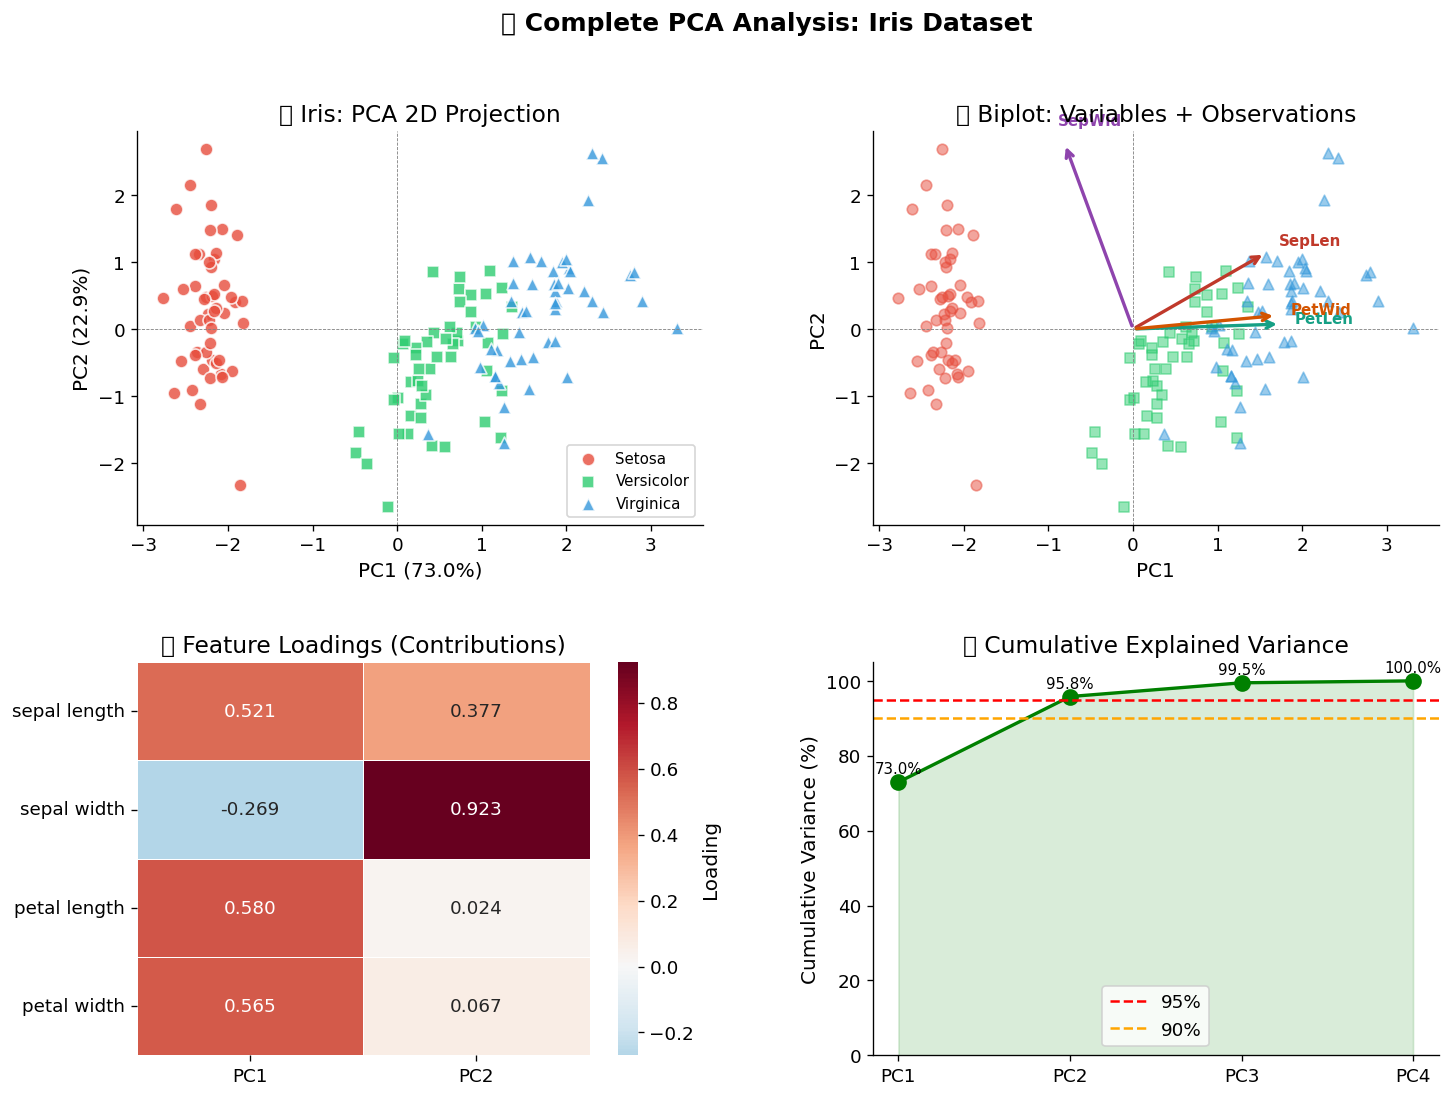


📋 Iris PCA Summary:
  Original: 4 features → After PCA: 2 components
  PC1 explains: 73.0%
  PC2 explains: 22.9%
  Total retained: 95.8%

  Interpretation:
  PC1 is driven mainly by petal measurements (size of flower)
  PC2 captures sepal shape differences


In [9]:
# ============================================================
#  IRIS DATASET — PCA Visualization
# ============================================================

iris = load_iris()
X_iris = iris.data
y_iris = iris.target
species = iris.target_names
feature_names_iris = iris.feature_names

# Standardize and apply PCA
scaler_i = StandardScaler()
X_std_i  = scaler_i.fit_transform(X_iris)
pca_i    = PCA(n_components=2)
X_pca_i  = pca_i.fit_transform(X_std_i)

# Create a nice DataFrame
df_iris = pd.DataFrame(X_pca_i, columns=['PC1', 'PC2'])
df_iris['Species'] = [species[t] for t in y_iris]

# ─── Figure: 4 subplots ──────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
gs  = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

colors_iris = {'setosa': '#e74c3c', 'versicolor': '#2ecc71', 'virginica': '#3498db'}
markers_iris = {'setosa': 'o', 'versicolor': 's', 'virginica': '^'}

# Plot 1: 2D PCA scatter
ax1 = fig.add_subplot(gs[0, 0])
for sp in species:
    mask = df_iris['Species'] == sp
    ax1.scatter(df_iris[mask]['PC1'], df_iris[mask]['PC2'],
                c=colors_iris[sp], marker=markers_iris[sp],
                s=60, alpha=0.8, edgecolors='white', label=sp.capitalize())
ax1.set_xlabel(f'PC1 ({pca_i.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca_i.explained_variance_ratio_[1]*100:.1f}%)')
ax1.set_title('🌸 Iris: PCA 2D Projection')
ax1.legend(fontsize=9)
ax1.axhline(0, color='gray', lw=0.5, ls='--'); ax1.axvline(0, color='gray', lw=0.5, ls='--')

# Plot 2: Biplot (PCA + Feature Loadings)
ax2 = fig.add_subplot(gs[0, 1])
for sp in species:
    mask = df_iris['Species'] == sp
    ax2.scatter(df_iris[mask]['PC1'], df_iris[mask]['PC2'],
                c=colors_iris[sp], marker=markers_iris[sp], s=40, alpha=0.5)

# Draw loading arrows
loadings = pca_i.components_.T
scale = 3
short_names = ['SepLen', 'SepWid', 'PetLen', 'PetWid']
arrow_colors = ['#c0392b', '#8e44ad', '#16a085', '#d35400']
for j, (feat, col) in enumerate(zip(short_names, arrow_colors)):
    ax2.annotate('', xy=(loadings[j,0]*scale, loadings[j,1]*scale),
                 xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color=col, lw=2))
    ax2.text(loadings[j,0]*scale*1.1, loadings[j,1]*scale*1.1,
             feat, color=col, fontsize=9, fontweight='bold')

ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
ax2.set_title('🗺️ Biplot: Variables + Observations')
ax2.axhline(0, color='gray', lw=0.5, ls='--'); ax2.axvline(0, color='gray', lw=0.5, ls='--')

# Plot 3: Loadings heatmap
ax3 = fig.add_subplot(gs[1, 0])
loadings_df = pd.DataFrame(pca_i.components_.T,
                            index=[n.replace(' (cm)', '') for n in feature_names_iris],
                            columns=['PC1', 'PC2'])
sns.heatmap(loadings_df, ax=ax3, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, linewidths=0.5,
            cbar_kws={'label': 'Loading'})
ax3.set_title('🔢 Feature Loadings (Contributions)')

# Plot 4: Cumulative variance
ax4 = fig.add_subplot(gs[1, 1])
pca_all = PCA().fit(X_std_i)
cum_var_all = np.cumsum(pca_all.explained_variance_ratio_) * 100
ax4.plot([f'PC{i+1}' for i in range(4)], cum_var_all, 'go-', lw=2, markersize=9)
ax4.fill_between([f'PC{i+1}' for i in range(4)], cum_var_all, alpha=0.15, color='green')
ax4.axhline(95, color='red', ls='--', lw=1.5, label='95%')
ax4.axhline(90, color='orange', ls='--', lw=1.5, label='90%')
ax4.set_ylabel('Cumulative Variance (%)')
ax4.set_title('📈 Cumulative Explained Variance')
ax4.legend(); ax4.set_ylim(0, 105)

for val, label in zip(cum_var_all, [f'PC{i+1}' for i in range(4)]):
    ax4.text(['PC1','PC2','PC3','PC4'].index(label), val + 1.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle('🌸 Complete PCA Analysis: Iris Dataset', fontsize=15, fontweight='bold')
plt.show()

print('\n📋 Iris PCA Summary:')
print(f'  Original: 4 features → After PCA: 2 components')
print(f'  PC1 explains: {pca_i.explained_variance_ratio_[0]*100:.1f}%')
print(f'  PC2 explains: {pca_i.explained_variance_ratio_[1]*100:.1f}%')
print(f'  Total retained: {sum(pca_i.explained_variance_ratio_)*100:.1f}%')
print(f'\n  Interpretation:')
print(f'  PC1 is driven mainly by petal measurements (size of flower)')
print(f'  PC2 captures sepal shape differences')

---
## 🏥 Section 8: Real-World Dataset — Breast Cancer

The **Breast Cancer Wisconsin** dataset has:
- **569 samples**, **30 features** (measurements of cell nuclei)
- **Binary label**: Malignant or Benign

This is a great example of PCA helping with a real classification problem!

Dataset: 569 samples, 30 features
Classes: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


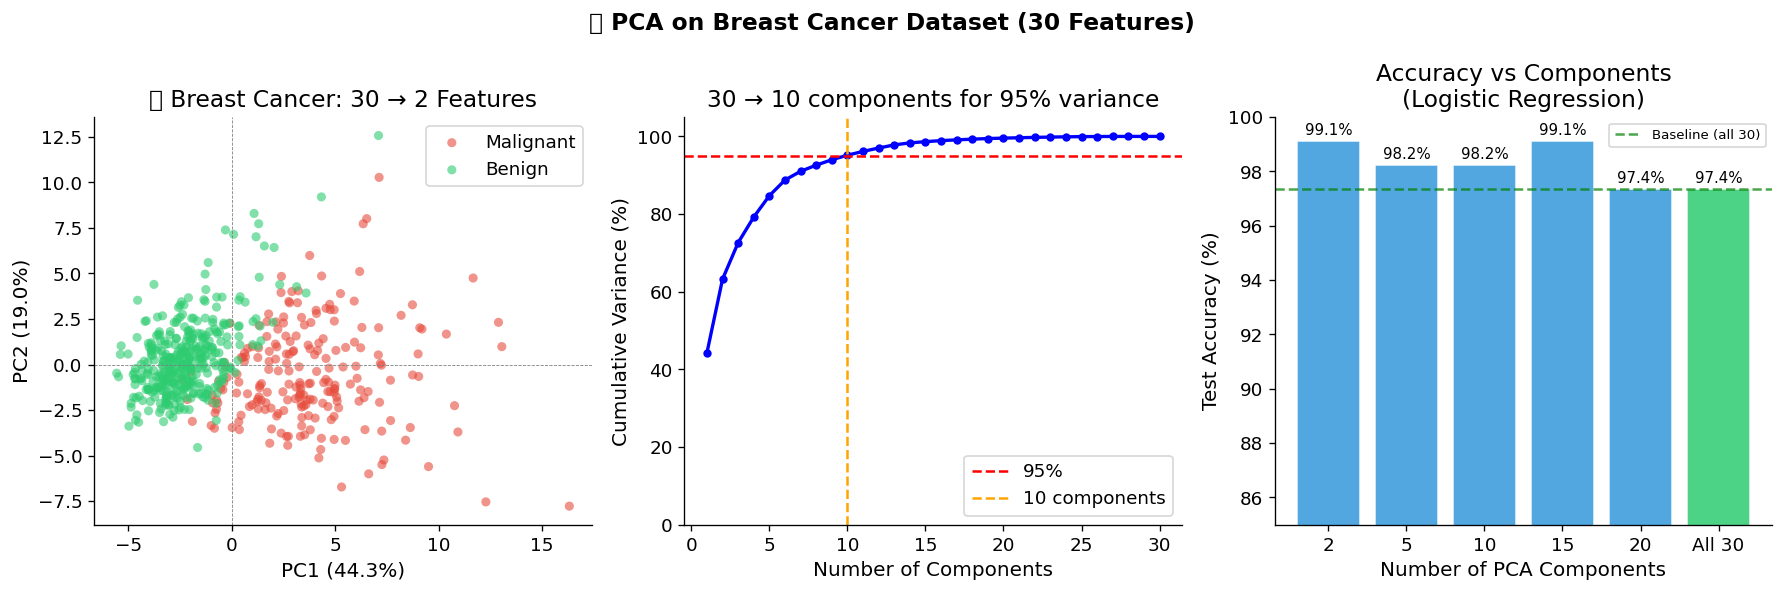


📋 Key Findings:
  30 features → 10 components captures 95% of variance
  With just 10 components, accuracy: 98.2%
  With all 30 features, accuracy:  97.4%
  Compression: 3.0x smaller, similar accuracy! 🎉


In [10]:
# ============================================================
#  BREAST CANCER — PCA for Dimensionality Reduction + ML
# ============================================================

cancer = load_breast_cancer()
X_bc   = cancer.data
y_bc   = cancer.target

print(f'Dataset: {X_bc.shape[0]} samples, {X_bc.shape[1]} features')
print(f'Classes: {dict(zip(cancer.target_names, np.bincount(y_bc)))}')

# Standardize
scaler_bc = StandardScaler()
X_bc_std  = scaler_bc.fit_transform(X_bc)

# PCA
pca_bc = PCA(n_components=2)
X_bc_2d = pca_bc.fit_transform(X_bc_std)

# PCA with enough components for 95% variance
pca_bc_full = PCA()
pca_bc_full.fit(X_bc_std)
cum_var_bc = np.cumsum(pca_bc_full.explained_variance_ratio_) * 100
n_95_bc    = np.argmax(cum_var_bc >= 95) + 1

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: 2D PCA scatter
colors_bc = {0: '#e74c3c', 1: '#2ecc71'}
for label, name in enumerate(cancer.target_names):
    mask = y_bc == label
    axes[0].scatter(X_bc_2d[mask, 0], X_bc_2d[mask, 1],
                    c=colors_bc[label], s=30, alpha=0.6,
                    edgecolors='none', label=name.capitalize())
axes[0].set_xlabel(f'PC1 ({pca_bc.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_bc.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('🏥 Breast Cancer: 30 → 2 Features')
axes[0].legend()
axes[0].axhline(0, color='gray', lw=0.5, ls='--')
axes[0].axvline(0, color='gray', lw=0.5, ls='--')

# Plot 2: Cumulative variance (30 components)
axes[1].plot(range(1, 31), cum_var_bc, 'b-o', lw=2, markersize=4)
axes[1].axhline(95, color='red', ls='--', lw=1.5, label='95%')
axes[1].axvline(n_95_bc, color='orange', ls='--', lw=1.5, label=f'{n_95_bc} components')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title(f'30 → {n_95_bc} components for 95% variance')
axes[1].legend(); axes[1].set_ylim(0, 105)

# Plot 3: ML Accuracy comparison
results = {}
for n_comp in [2, 5, 10, 15, 20, 30]:
    if n_comp == 30:
        X_use = X_bc_std
        label = 'All 30'
    else:
        pca_temp = PCA(n_components=n_comp)
        X_use = pca_temp.fit_transform(X_bc_std)
        label = str(n_comp)

    X_tr, X_te, y_tr, y_te = train_test_split(X_use, y_bc, test_size=0.2, random_state=42)
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, clf.predict(X_te))
    results[label] = acc * 100

bars = axes[2].bar(results.keys(), results.values(),
                   color=['#3498db']*5 + ['#2ecc71'], alpha=0.85, edgecolor='white')
axes[2].set_xlabel('Number of PCA Components')
axes[2].set_ylabel('Test Accuracy (%)')
axes[2].set_title('Accuracy vs Components\n(Logistic Regression)')
axes[2].set_ylim(85, 100)
for bar, val in zip(bars, results.values()):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

axes[2].axhline(list(results.values())[-1], color='green', ls='--', lw=1.5, alpha=0.7, label='Baseline (all 30)')
axes[2].legend(fontsize=8)

plt.suptitle('🏥 PCA on Breast Cancer Dataset (30 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n📋 Key Findings:')
print(f'  30 features → {n_95_bc} components captures 95% of variance')
print(f'  With just 10 components, accuracy: {results["10"]:.1f}%')
print(f'  With all 30 features, accuracy:  {results["All 30"]:.1f}%')
print(f'  Compression: {30/10:.1f}x smaller, similar accuracy! 🎉')

---
## 🖼️ Section 9: Image Compression with PCA

One of the coolest applications of PCA! We can compress images by keeping only the top principal components.

Each image row is treated as a sample, and columns as features. PCA finds the most important "patterns" in the image.

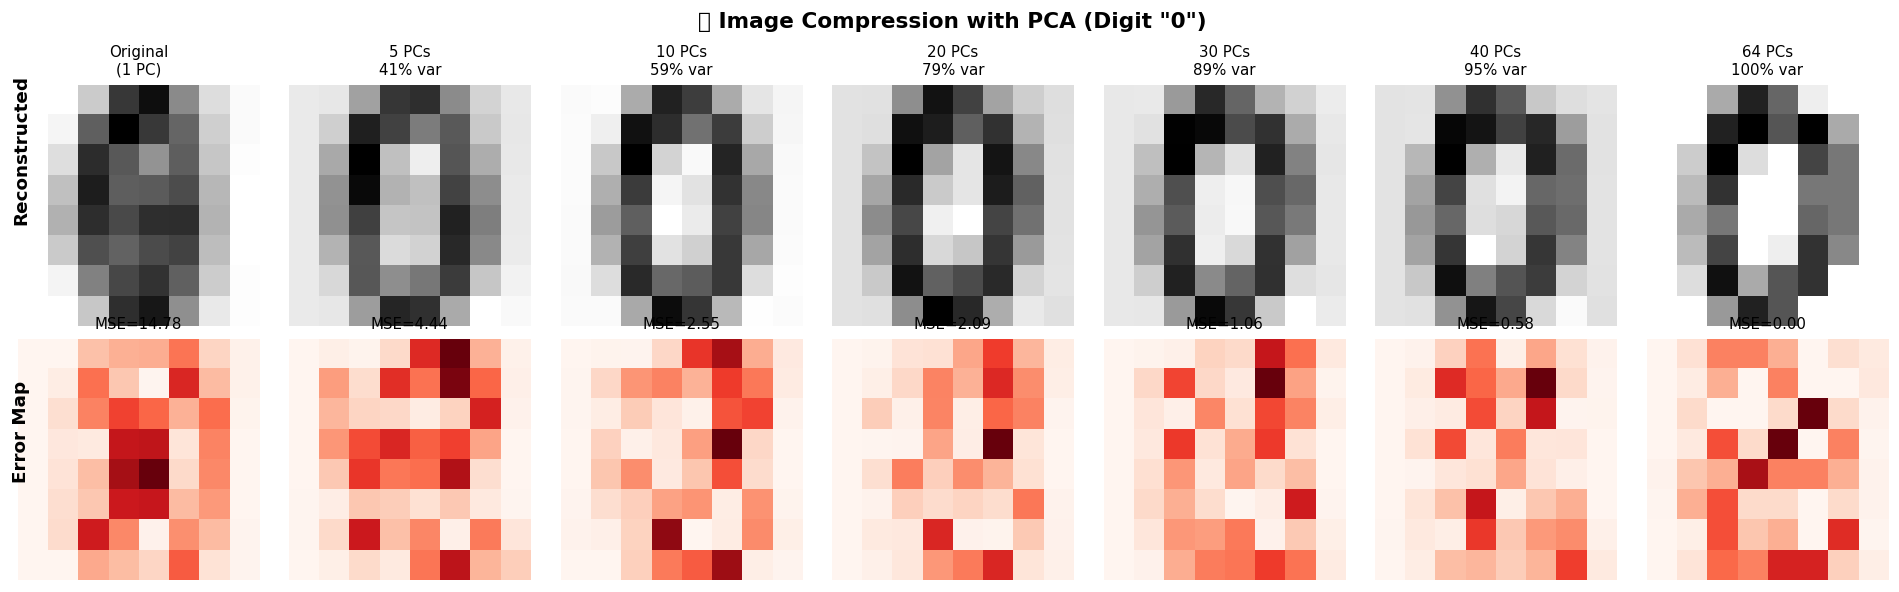

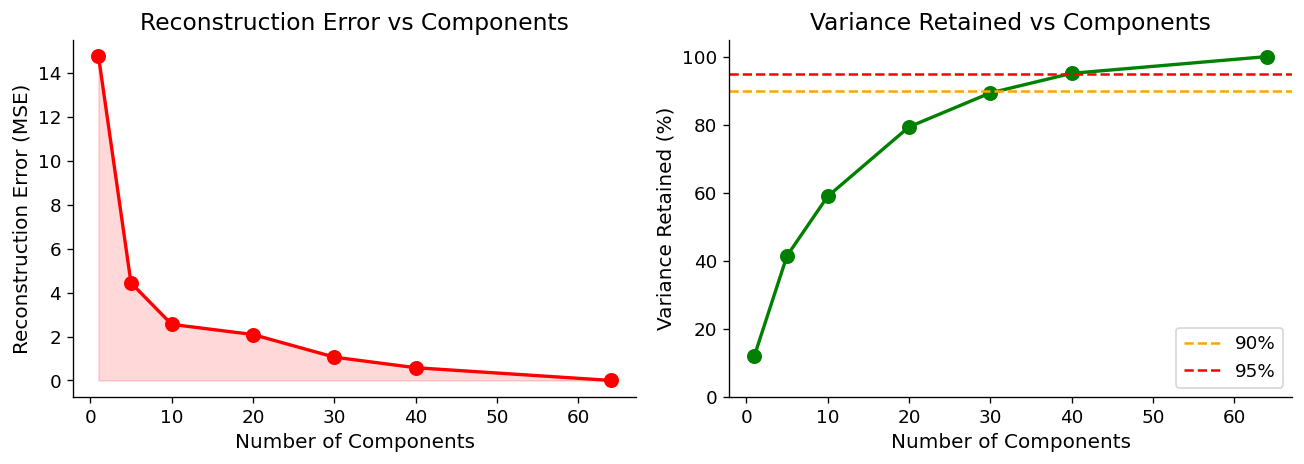


💡 Key Insight:
   Just 20 components (out of 64) give excellent reconstruction!
   That is a 3.2x compression with minimal quality loss.


In [11]:
# ============================================================
#  IMAGE COMPRESSION WITH PCA — Digits Dataset
# ============================================================

digits = load_digits()
X_digits = digits.data   # 1797 samples, 64 features (8x8 images)

# Use a single digit image for compression demo
# We'll use the full dataset matrix for PCA
scaler_dig = StandardScaler()
X_dig_std  = scaler_dig.fit_transform(X_digits)

# Try different numbers of components
n_components_list = [1, 5, 10, 20, 30, 40, 64]

fig, axes = plt.subplots(2, len(n_components_list), figsize=(16, 5))

original_img = X_digits[0].reshape(8, 8)

mse_values  = []
comp_ratios = []

for col, n_comp in enumerate(n_components_list):
    pca_d = PCA(n_components=n_comp)
    X_compressed = pca_d.fit_transform(X_dig_std)
    X_reconstructed_std = pca_d.inverse_transform(X_compressed)
    X_reconstructed = scaler_dig.inverse_transform(X_reconstructed_std)

    # Reconstruct first image
    recon_img = X_reconstructed[0].reshape(8, 8)
    mse = np.mean((original_img - recon_img)**2)
    var_ret = sum(pca_d.explained_variance_ratio_) * 100

    mse_values.append(mse)
    comp_ratios.append(var_ret)

    # Top row: reconstructed images
    axes[0, col].imshow(recon_img, cmap='gray_r', interpolation='nearest')
    axes[0, col].set_title(f'{n_comp} PCs\n{var_ret:.0f}% var', fontsize=9)
    axes[0, col].axis('off')

    # Bottom row: error map
    error_map = np.abs(original_img - recon_img)
    im = axes[1, col].imshow(error_map, cmap='Reds', interpolation='nearest')
    axes[1, col].set_title(f'MSE={mse:.2f}', fontsize=9)
    axes[1, col].axis('off')

axes[0, 0].set_title(f'Original\n(1 PC)', fontsize=9)
fig.text(0.01, 0.75, 'Reconstructed', va='center', rotation='vertical', fontsize=11, fontweight='bold')
fig.text(0.01, 0.28, 'Error Map', va='center', rotation='vertical', fontsize=11, fontweight='bold')

plt.suptitle('🖼️ Image Compression with PCA (Digit "0")', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Second plot: MSE vs components
fig2, (ax_mse, ax_var) = plt.subplots(1, 2, figsize=(11, 4))

ax_mse.plot(n_components_list, mse_values, 'ro-', lw=2, markersize=8)
ax_mse.set_xlabel('Number of Components')
ax_mse.set_ylabel('Reconstruction Error (MSE)')
ax_mse.set_title('Reconstruction Error vs Components')
ax_mse.fill_between(n_components_list, mse_values, alpha=0.15, color='red')

ax_var.plot(n_components_list, comp_ratios, 'go-', lw=2, markersize=8)
ax_var.axhline(90, color='orange', ls='--', label='90%')
ax_var.axhline(95, color='red', ls='--', label='95%')
ax_var.set_xlabel('Number of Components')
ax_var.set_ylabel('Variance Retained (%)')
ax_var.set_title('Variance Retained vs Components')
ax_var.legend(); ax_var.set_ylim(0, 105)

plt.tight_layout()
plt.show()

print('\n💡 Key Insight:')
print('   Just 20 components (out of 64) give excellent reconstruction!')
print('   That is a 3.2x compression with minimal quality loss.')

---
## 🔕 Section 10: PCA for Noise Reduction

PCA can act as a **denoising filter**! The idea:
- The **signal** (true data) lives in the top principal components
- **Noise** is spread across many small components
- By keeping only the top components and reconstructing, we remove noise!

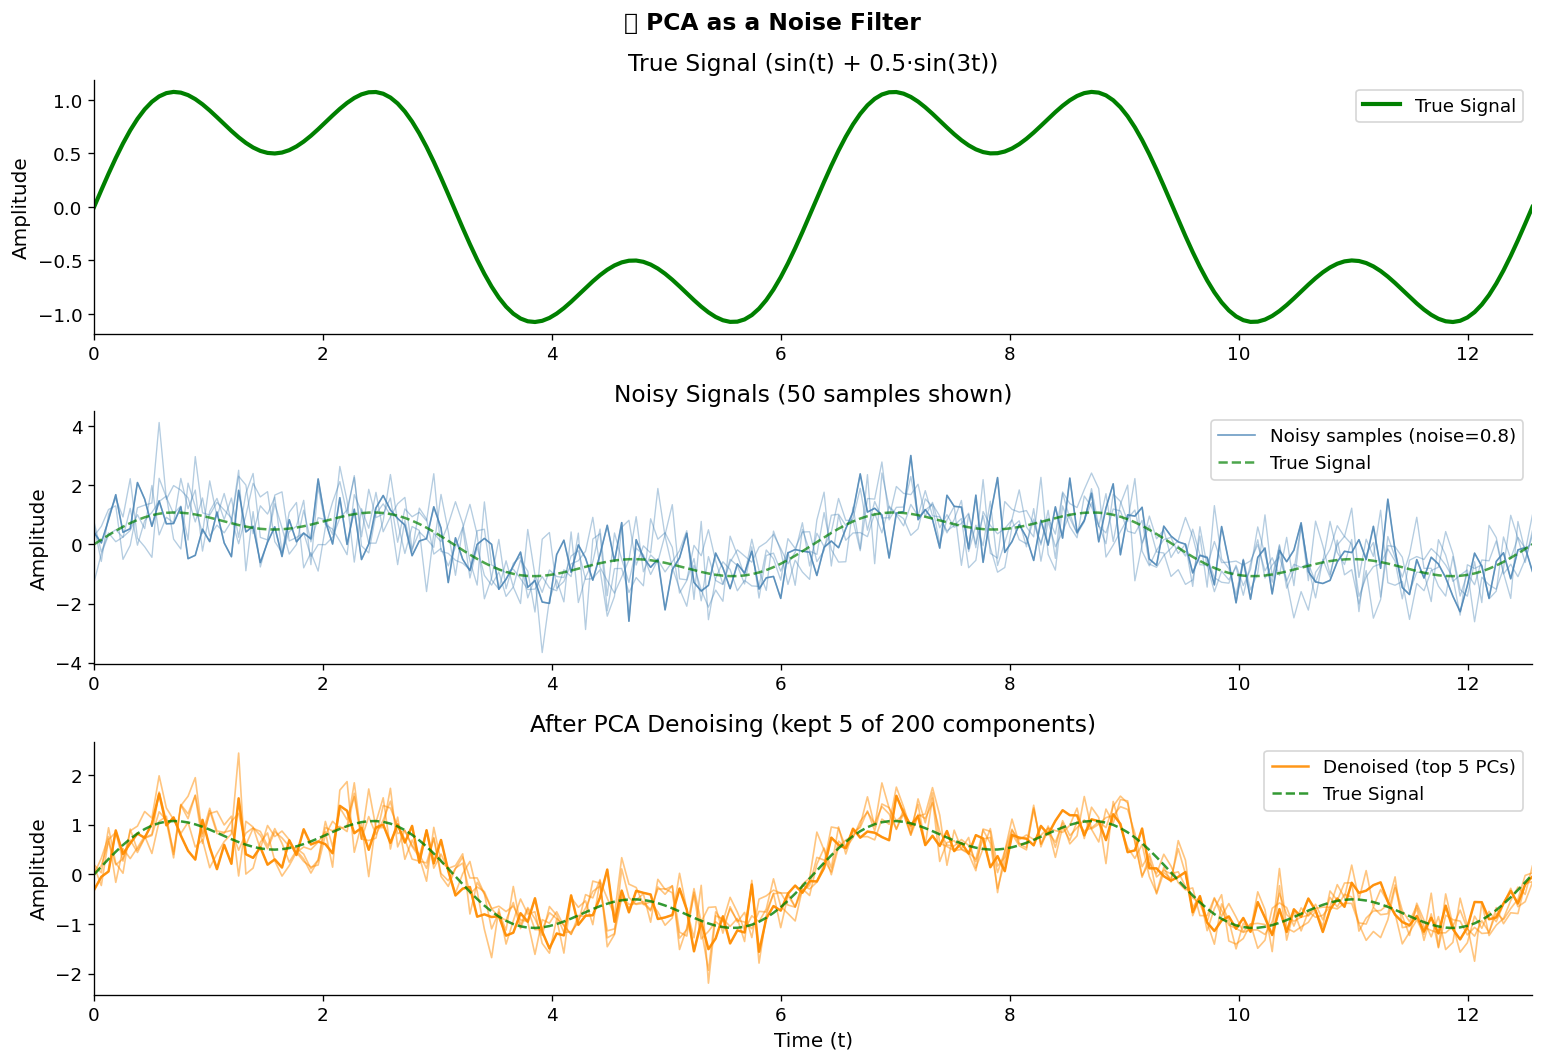

📊 Denoising Results:
   MSE (noisy):    0.5530
   MSE (denoised): 0.0799
   Improvement:    85.6% error reduction 🎉

💡 PCA kept only 5/200 = 2.5% of components
   and captured the true signal, discarding the noise!


In [12]:
# ============================================================
#  PCA FOR NOISE REDUCTION
# ============================================================

np.random.seed(42)
n = 200
t = np.linspace(0, 4*np.pi, n)

# True signal: a smooth sine wave
true_signal = np.sin(t) + 0.5*np.sin(3*t)

# Add noise to create a dataset (each sample is the signal + different noise)
n_samples = 50
noise_level = 0.8
X_noisy = np.array([true_signal + noise_level * np.random.randn(n) for _ in range(n_samples)])

# Apply PCA and keep only top k components
k = 5  # Keep top 5 components
pca_noise = PCA(n_components=k)
X_compressed = pca_noise.fit_transform(X_noisy)
X_denoised   = pca_noise.inverse_transform(X_compressed)

# Plot results
fig, axes = plt.subplots(3, 1, figsize=(13, 9))

# True signal
axes[0].plot(t, true_signal, 'g-', lw=2.5, label='True Signal')
axes[0].set_title('True Signal (sin(t) + 0.5·sin(3t))')
axes[0].set_ylabel('Amplitude'); axes[0].legend()
axes[0].set_xlim(t[0], t[-1])

# Noisy signals
for i in range(5):
    axes[1].plot(t, X_noisy[i], alpha=0.4, lw=0.8, color='steelblue')
axes[1].plot(t, X_noisy[0], alpha=0.8, lw=1, color='steelblue', label=f'Noisy samples (noise={noise_level})')
axes[1].plot(t, true_signal, 'g--', lw=1.5, alpha=0.7, label='True Signal')
axes[1].set_title(f'Noisy Signals (50 samples shown)')
axes[1].set_ylabel('Amplitude'); axes[1].legend()
axes[1].set_xlim(t[0], t[-1])

# Denoised
for i in range(5):
    axes[2].plot(t, X_denoised[i], alpha=0.5, lw=1, color='darkorange')
axes[2].plot(t, X_denoised[0], alpha=0.9, lw=1.5, color='darkorange', label=f'Denoised (top {k} PCs)')
axes[2].plot(t, true_signal, 'g--', lw=1.5, alpha=0.8, label='True Signal')
axes[2].set_title(f'After PCA Denoising (kept {k} of {n} components)')
axes[2].set_ylabel('Amplitude'); axes[2].set_xlabel('Time (t)')
axes[2].legend(); axes[2].set_xlim(t[0], t[-1])

plt.suptitle('🔕 PCA as a Noise Filter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Compute SNR improvement
mse_noisy    = np.mean((X_noisy[0] - true_signal)**2)
mse_denoised = np.mean((X_denoised[0] - true_signal)**2)
improvement  = (1 - mse_denoised/mse_noisy) * 100

print(f'📊 Denoising Results:')
print(f'   MSE (noisy):    {mse_noisy:.4f}')
print(f'   MSE (denoised): {mse_denoised:.4f}')
print(f'   Improvement:    {improvement:.1f}% error reduction 🎉')
print(f'\n💡 PCA kept only {k}/{n} = {k/n*100:.1f}% of components')
print(f'   and captured the true signal, discarding the noise!')

---
## ⚠️ Section 11: Limitations & When NOT to Use PCA

PCA is powerful, but it's not always the right tool!

### ❌ When NOT to Use PCA

| Situation | Why PCA Struggles |
|-----------|------------------|
| Non-linear relationships | PCA is **linear only** — it can't capture complex curves |
| Interpretability matters | Components are hard to interpret (they mix features) |
| Categorical features | PCA works on **numerical** data only |
| When you need causal insight | PCA finds correlation, not causation |
| Very sparse data | PCA doesn't handle sparse matrices well |

### ✅ Alternatives for Non-Linear Data
- **t-SNE**: Great for visualization
- **UMAP**: Faster than t-SNE, also great for visualization
- **Kernel PCA**: Non-linear version of PCA
- **Autoencoders**: Deep learning approach

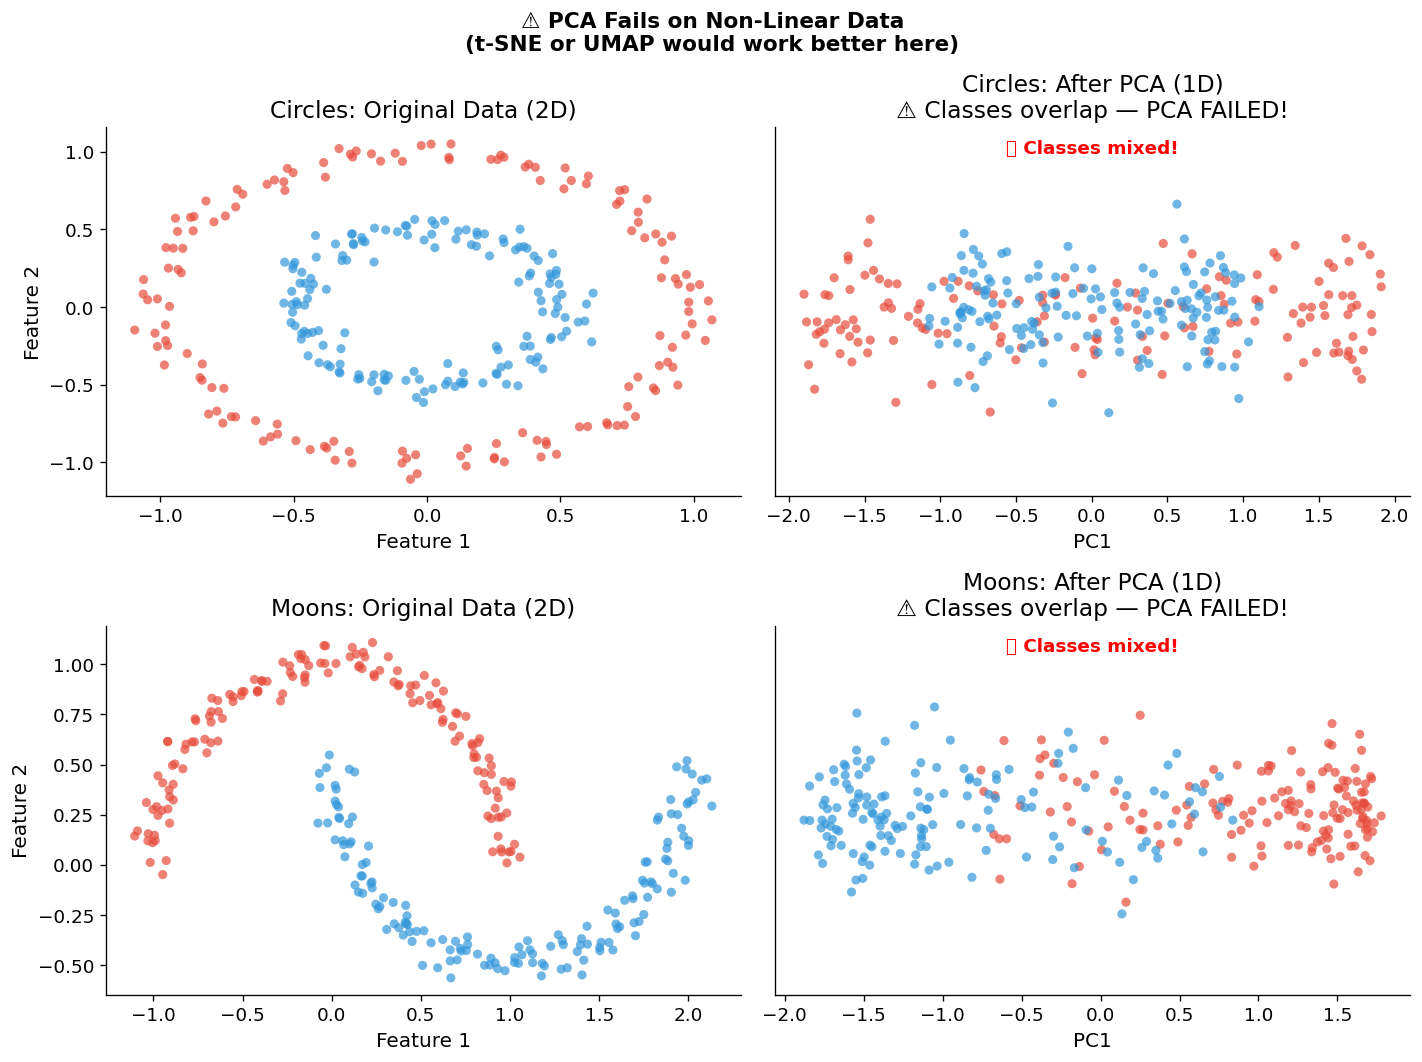

💡 Takeaway:
   PCA assumes data lies on a LINEAR subspace.
   For circle/moon-shaped clusters, the classes are NOT separable by a line.
   Use t-SNE, UMAP, or Kernel PCA for non-linear structure!


In [13]:
# ============================================================
#  DEMO: Where PCA Fails — Non-Linear Data
# ============================================================

from sklearn.datasets import make_circles, make_moons

# Generate non-linear datasets
X_circles, y_circles = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)
X_moons, y_moons     = make_moons(n_samples=300, noise=0.05, random_state=42)

datasets = [
    ('Circles', X_circles, y_circles),
    ('Moons',   X_moons,   y_moons)
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

colors_nl = ['#e74c3c', '#3498db']

for row, (name, X_nl, y_nl) in enumerate(datasets):
    # Original data
    for cls in [0, 1]:
        mask = y_nl == cls
        axes[row, 0].scatter(X_nl[mask, 0], X_nl[mask, 1],
                             c=colors_nl[cls], s=30, alpha=0.7, edgecolors='none')
    axes[row, 0].set_title(f'{name}: Original Data (2D)')
    axes[row, 0].set_xlabel('Feature 1'); axes[row, 0].set_ylabel('Feature 2')

    # PCA projection to 1D then back
    pca_nl = PCA(n_components=1)
    scaler_nl = StandardScaler()
    X_nl_std = scaler_nl.fit_transform(X_nl)
    X_nl_1d  = pca_nl.fit_transform(X_nl_std)

    for cls in [0, 1]:
        mask = y_nl == cls
        axes[row, 1].scatter(X_nl_1d[mask, 0],
                             np.zeros(mask.sum()) + np.random.randn(mask.sum())*0.04,
                             c=colors_nl[cls], s=30, alpha=0.7, edgecolors='none')
    axes[row, 1].set_title(f'{name}: After PCA (1D)\n⚠️ Classes overlap — PCA FAILED!')
    axes[row, 1].set_xlabel('PC1'); axes[row, 1].set_ylabel('')
    axes[row, 1].set_yticks([])
    axes[row, 1].set_ylim(-0.2, 0.2)

    # Annotate failure
    axes[row, 1].text(0.5, 0.93, '❌ Classes mixed!',
                      transform=axes[row, 1].transAxes,
                      ha='center', color='red', fontweight='bold', fontsize=11)

plt.suptitle('⚠️ PCA Fails on Non-Linear Data\n(t-SNE or UMAP would work better here)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Takeaway:')
print('   PCA assumes data lies on a LINEAR subspace.')
print('   For circle/moon-shaped clusters, the classes are NOT separable by a line.')
print('   Use t-SNE, UMAP, or Kernel PCA for non-linear structure!')

---
## 🆚 Section 12: PCA vs Other Dimensionality Reduction Techniques

| Method | Type | Good For | Weakness |
|--------|------|----------|----------|
| **PCA** | Linear | General purpose, preprocessing | Misses non-linear structure |
| **t-SNE** | Non-linear | Visualization (2D/3D) | Slow, not for new data |
| **UMAP** | Non-linear | Visualization + downstream ML | Less interpretable |
| **Kernel PCA** | Non-linear | Small to medium datasets | Slow on large data |
| **LDA** | Linear | Classification tasks | Supervised only |
| **Autoencoders** | Non-linear | Complex patterns, images | Needs lots of data + GPU |

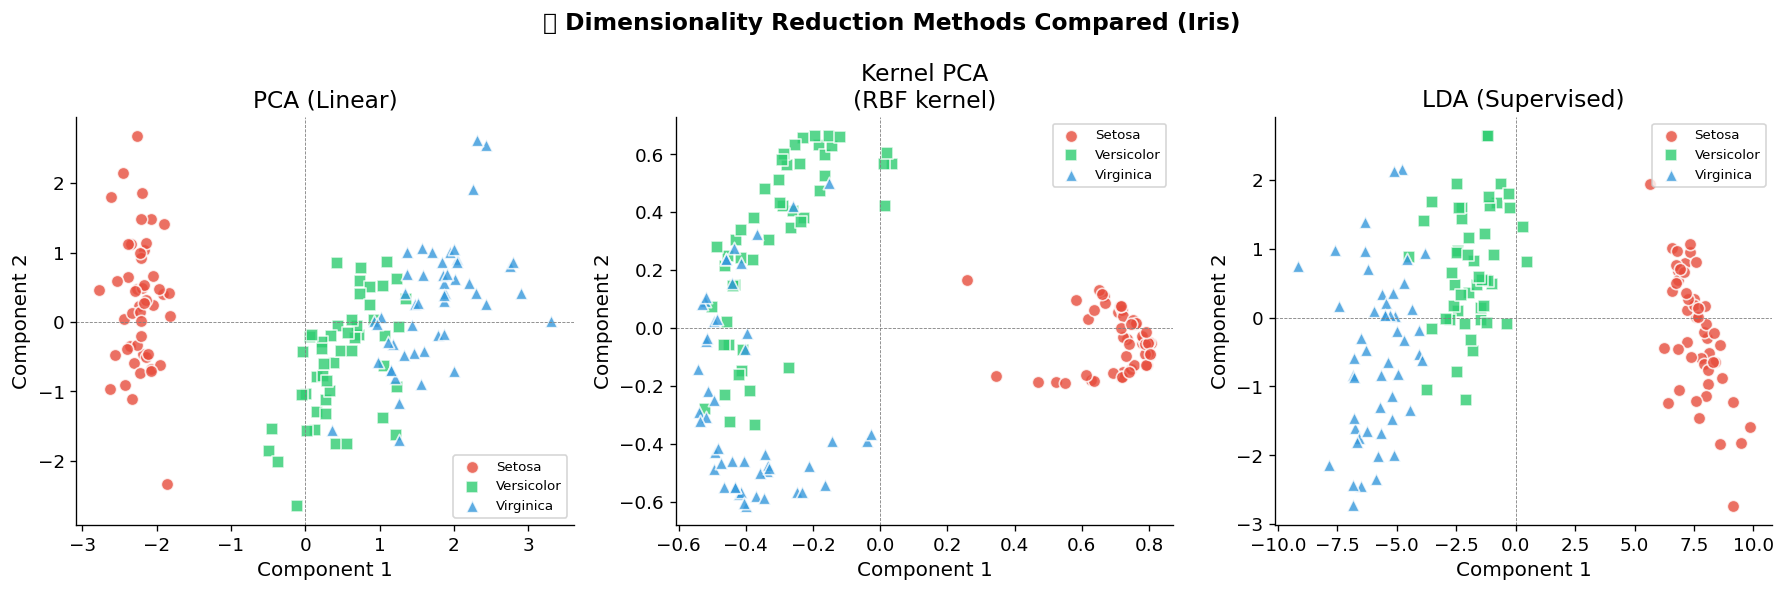

📋 Observations:
   PCA:       Good separation, unsupervised, interpretable
   Kernel PCA: Can find non-linear structure (RBF kernel here)
   LDA:       Best class separation (uses labels = supervised)

💡 Rule of thumb:
   → Use PCA for preprocessing and general exploration
   → Use LDA if you have labels and want max separability
   → Use t-SNE/UMAP for visualization of complex data


In [14]:
# ============================================================
#  COMPARISON: PCA vs Kernel PCA vs LDA on Iris
# ============================================================

from sklearn.decomposition import KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

iris = load_iris()
X_c  = iris.data
y_c  = iris.target
sp   = iris.target_names

scaler_c = StandardScaler()
X_c_std  = scaler_c.fit_transform(X_c)

methods = {
    'PCA (Linear)':   PCA(n_components=2).fit_transform(X_c_std),
    'Kernel PCA\n(RBF kernel)': KernelPCA(n_components=2, kernel='rbf').fit_transform(X_c_std),
    'LDA (Supervised)': LinearDiscriminantAnalysis(n_components=2).fit_transform(X_c_std, y_c),
}

colors_c  = ['#e74c3c', '#2ecc71', '#3498db']
markers_c = ['o', 's', '^']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (method_name, X_transformed) in zip(axes, methods.items()):
    for label, name, color, marker in zip([0,1,2], sp, colors_c, markers_c):
        mask = y_c == label
        ax.scatter(X_transformed[mask, 0], X_transformed[mask, 1],
                   c=color, marker=marker, s=55, alpha=0.8,
                   edgecolors='white', label=name.capitalize())
    ax.set_title(method_name)
    ax.set_xlabel('Component 1'); ax.set_ylabel('Component 2')
    ax.legend(fontsize=8)
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.axvline(0, color='gray', lw=0.5, ls='--')

plt.suptitle('🆚 Dimensionality Reduction Methods Compared (Iris)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('📋 Observations:')
print('   PCA:       Good separation, unsupervised, interpretable')
print('   Kernel PCA: Can find non-linear structure (RBF kernel here)')
print('   LDA:       Best class separation (uses labels = supervised)')
print('\n💡 Rule of thumb:')
print('   → Use PCA for preprocessing and general exploration')
print('   → Use LDA if you have labels and want max separability')
print('   → Use t-SNE/UMAP for visualization of complex data')

---
## 📝 Section 13: Summary & Cheat Sheet

Congratulations! 🎉 You've completed the PCA course. Let's recap everything.

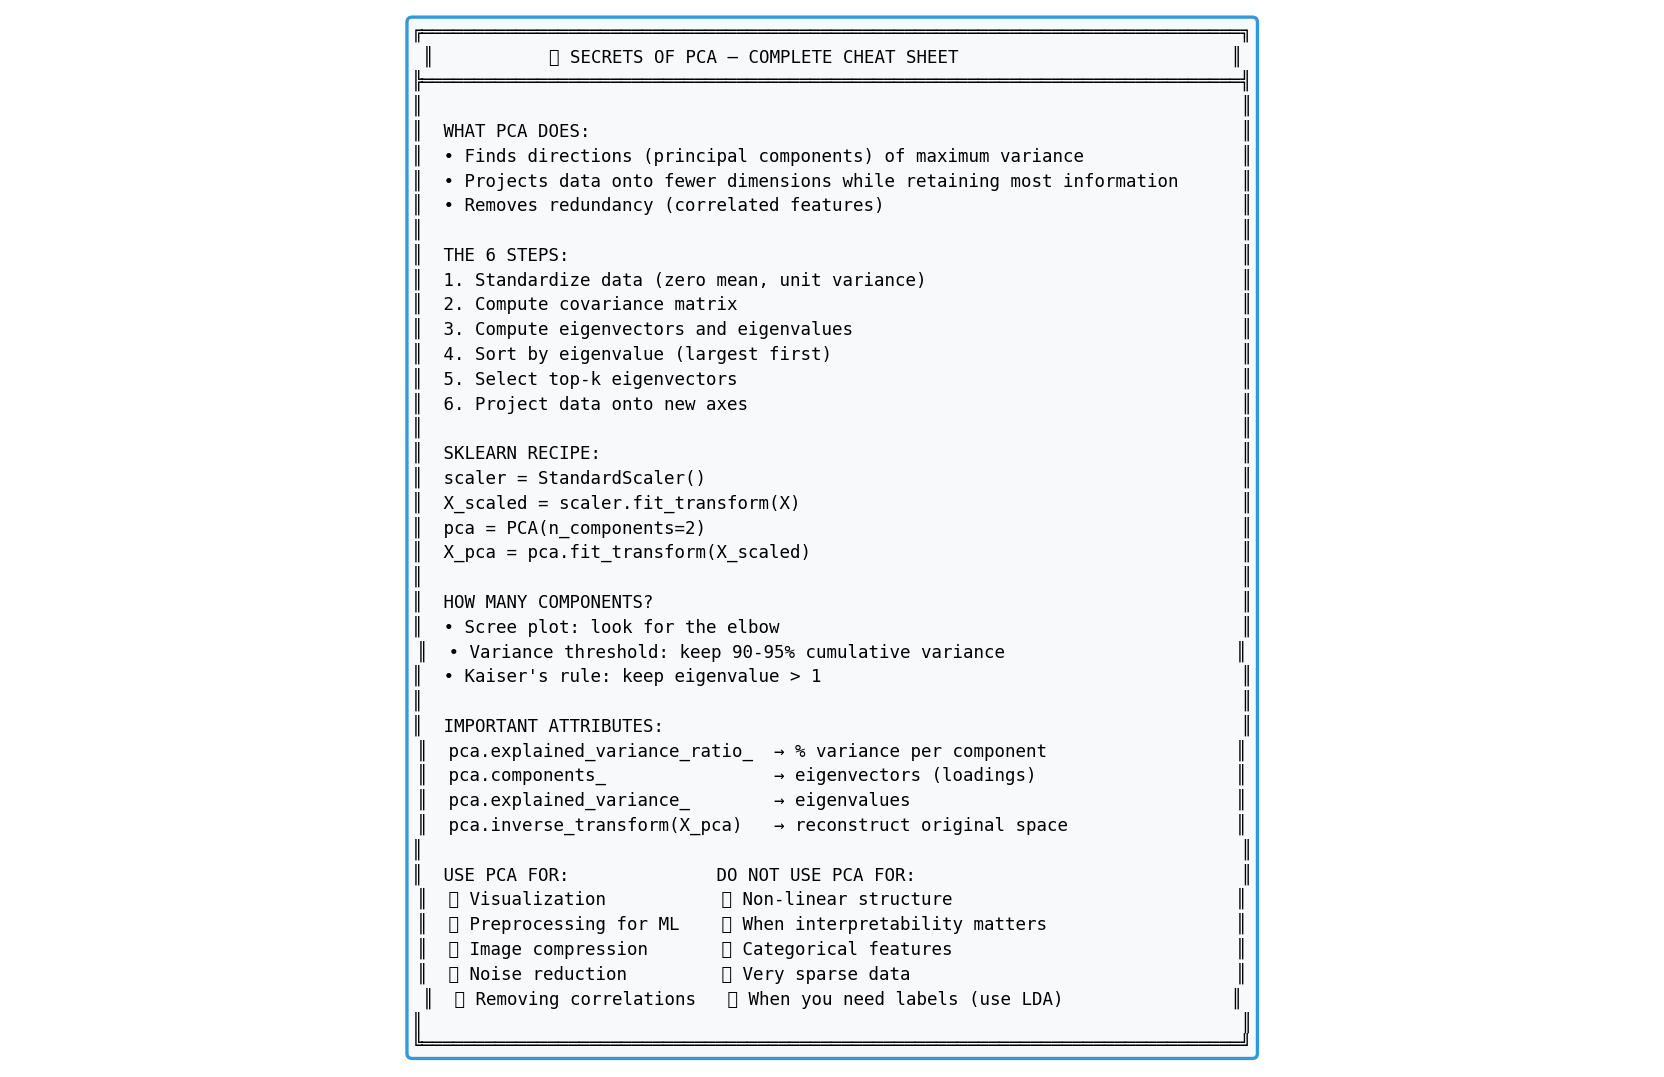

In [15]:
# ============================================================
#  FINAL SUMMARY VISUALIZATION
# ============================================================

fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('off')

summary_text = """╔══════════════════════════════════════════════════════════════════════════════╗
║           🔍 SECRETS OF PCA — COMPLETE CHEAT SHEET                          ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  WHAT PCA DOES:                                                              ║
║  • Finds directions (principal components) of maximum variance               ║
║  • Projects data onto fewer dimensions while retaining most information      ║
║  • Removes redundancy (correlated features)                                  ║
║                                                                              ║
║  THE 6 STEPS:                                                                ║
║  1. Standardize data (zero mean, unit variance)                              ║
║  2. Compute covariance matrix                                                ║
║  3. Compute eigenvectors and eigenvalues                                     ║
║  4. Sort by eigenvalue (largest first)                                       ║
║  5. Select top-k eigenvectors                                                ║
║  6. Project data onto new axes                                               ║
║                                                                              ║
║  SKLEARN RECIPE:                                                             ║
║  scaler = StandardScaler()                                                   ║
║  X_scaled = scaler.fit_transform(X)                                          ║
║  pca = PCA(n_components=2)                                                   ║
║  X_pca = pca.fit_transform(X_scaled)                                         ║
║                                                                              ║
║  HOW MANY COMPONENTS?                                                        ║
║  • Scree plot: look for the elbow                                            ║
║  • Variance threshold: keep 90-95% cumulative variance                      ║
║  • Kaiser's rule: keep eigenvalue > 1                                        ║
║                                                                              ║
║  IMPORTANT ATTRIBUTES:                                                       ║
║  pca.explained_variance_ratio_  → % variance per component                  ║
║  pca.components_                → eigenvectors (loadings)                   ║
║  pca.explained_variance_        → eigenvalues                               ║
║  pca.inverse_transform(X_pca)   → reconstruct original space                ║
║                                                                              ║
║  USE PCA FOR:              DO NOT USE PCA FOR:                               ║
║  ✅ Visualization           ❌ Non-linear structure                           ║
║  ✅ Preprocessing for ML    ❌ When interpretability matters                  ║
║  ✅ Image compression       ❌ Categorical features                           ║
║  ✅ Noise reduction         ❌ Very sparse data                               ║
║  ✅ Removing correlations   ❌ When you need labels (use LDA)                ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝"""

ax.text(0.5, 0.5, summary_text, transform=ax.transAxes,
        fontsize=10.5, verticalalignment='center', horizontalalignment='center',
        fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f8f9fa', edgecolor='#3498db', linewidth=2))

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
#  🧠 KNOWLEDGE CHECK — Quick Quiz
# ============================================================

print('🧠 KNOWLEDGE CHECK')
print('=' * 50)

quiz = [
    {
        'q': 'What does PCA stand for?',
        'a': 'Principal Component Analysis'
    },
    {
        'q': 'What should you ALWAYS do before applying PCA?',
        'a': 'Standardize the data (zero mean, unit variance)'
    },
    {
        'q': 'What do eigenvalues tell us in PCA?',
        'a': 'How much variance each principal component explains'
    },
    {
        'q': 'If PC1 explains 80% and PC2 explains 15%, what is the cumulative variance for 2 components?',
        'a': '95%'
    },
    {
        'q': 'Is PCA supervised or unsupervised?',
        'a': 'Unsupervised (it does not use labels)'
    },
    {
        'q': 'What technique should you use instead of PCA for non-linear data visualization?',
        'a': 't-SNE or UMAP'
    },
    {
        'q': 'In PCA, what does pca.components_ contain?',
        'a': 'The eigenvectors (directions/loadings of each principal component)'
    },
]

for i, item in enumerate(quiz, 1):
    print(f'\nQ{i}: {item["q"]}')
    print(f'  → Answer: {item["a"]}')

print('\n' + '=' * 50)
print('🎉 Congratulations on completing Secrets of PCA!')
print('   You now understand one of the most fundamental')
print('   techniques in machine learning and data science.')
print('\n   Keep exploring! Next steps:')
print('   → Try t-SNE on the digits dataset')
print('   → Explore Kernel PCA with different kernels')
print('   → Apply PCA to your own dataset!')

🧠 KNOWLEDGE CHECK

Q1: What does PCA stand for?
  → Answer: Principal Component Analysis

Q2: What should you ALWAYS do before applying PCA?
  → Answer: Standardize the data (zero mean, unit variance)

Q3: What do eigenvalues tell us in PCA?
  → Answer: How much variance each principal component explains

Q4: If PC1 explains 80% and PC2 explains 15%, what is the cumulative variance for 2 components?
  → Answer: 95%

Q5: Is PCA supervised or unsupervised?
  → Answer: Unsupervised (it does not use labels)

Q6: What technique should you use instead of PCA for non-linear data visualization?
  → Answer: t-SNE or UMAP

Q7: In PCA, what does pca.components_ contain?
  → Answer: The eigenvectors (directions/loadings of each principal component)

🎉 Congratulations on completing Secrets of PCA!
   You now understand one of the most fundamental
   techniques in machine learning and data science.

   Keep exploring! Next steps:
   → Try t-SNE on the digits dataset
   → Explore Kernel PCA with diff

---

## 🚀 Next Steps & Further Reading

### 📚 Resources
- [Scikit-learn PCA Documentation](https://scikit-learn.org/stable/modules/decomposition.html#pca)
- [StatQuest: PCA Step-by-Step (YouTube)](https://www.youtube.com/watch?v=FgakZw6K1QQ)
- [Making sense of PCA (towardsdatascience.com)](https://towardsdatascience.com/)
- [Secrets of PCA: A Comprehensive Guide to Principal Component Analysis with Python and Colab - Dr. Ernesto Lee](https://drlee.io/secrets-of-pca-a-comprehensive-guide-to-principal-component-analysis-with-python-and-colab-6f7f3142e721)


### 🏋️ Practice Projects
1. **Apply PCA to the Wine Dataset** (sklearn.datasets.load_wine) — can you visualize the 3 wine types in 2D?
2. **Face Recognition** — use PCA ("Eigenfaces") on the Olivetti Faces dataset
3. **Stock Market PCA** — download stock prices with yfinance and find hidden factors
4. **Compare PCA vs t-SNE** on the MNIST digits dataset

### 🧩 Key Formulas

$$\text{Covariance Matrix:} \quad C = \frac{1}{n-1} X^T X$$

$$\text{Eigendecomposition:} \quad C \mathbf{v} = \lambda \mathbf{v}$$

$$\text{Projection:} \quad X_{\text{PCA}} = X \cdot W_k$$

$$\text{Variance Explained:} \quad \text{ratio}_i = \frac{\lambda_i}{\sum_j \lambda_j}$$

---
*Made with ❤️ | Secrets of PCA — A Beginner's Complete Guide*